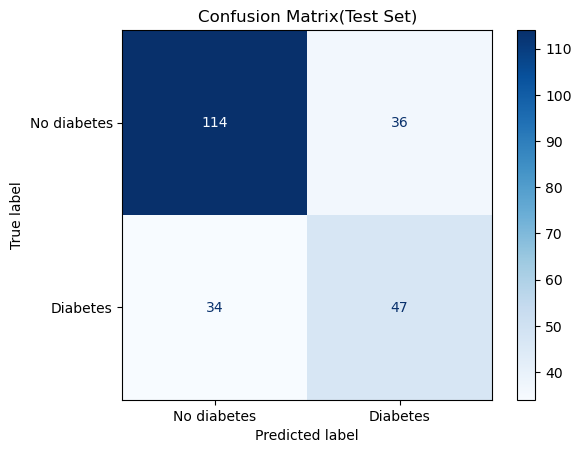

              precision    recall  f1-score   support

           0       0.77      0.76      0.77       150
           1       0.57      0.58      0.57        81

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



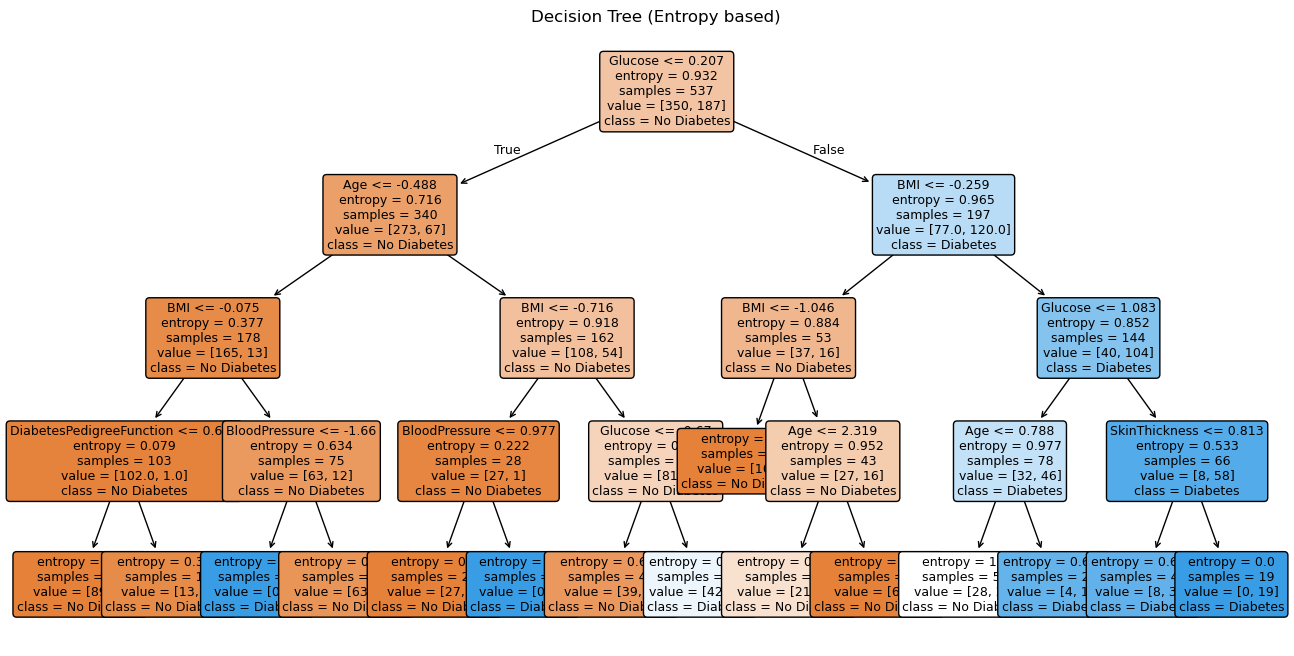

In [2]:
# Decision tree for diabetes dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes.csv')
x = df.drop('Outcome',axis=1)
y = df['Outcome']

scaler = StandardScaler()
x[x.columns]=scaler.fit_transform(x[x.columns])

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=101)
model = DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=['No diabetes','Diabetes']).plot(cmap='Blues')
plt.title('Confusion Matrix(Test Set)')
plt.show()
print(classification_report(y_test, y_pred))

# visualize the decision tree
plt.figure(figsize=(16,8))
plot_tree(model, feature_names=x.columns, class_names=['No Diabetes','Diabetes'],
          filled=True, rounded=True,fontsize=9)
plt.title('Decision Tree (Entropy based)')
plt.show()